## Training Model

In [1]:
# 1. Mount Google Drive
from google.colab import drive
import os
drive.mount('/content/drive')

# 2. Change Directory to your Project
# Replace 'VisionGuard' with your actual folder name on Drive
PROJECT_PATH = "/content/drive/MyDrive/VisionGuard"
os.chdir(PROJECT_PATH)

# 3. Verify files are there
!ls
print(f"Current Working Directory: {os.getcwd()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
metadata.csv  raw.zip  src  training_log.csv
Current Working Directory: /content/drive/MyDrive/VisionGuard


In [2]:
import pandas as pd
import os
from src.indexer import create_manifest
from src.generator import VideoGenerator

# 1. Define the exact path for the CSV
csv_path = "/content/drive/MyDrive/VisionGuard/metadata.csv"

# 2. Run the Indexer (This creates the file if it's missing)
print("--- Step 1: Indexing Videos ---")
create_manifest() 

# 3. Verify the file actually exists now
if os.path.exists(csv_path):
    print(f"Success: {csv_path} found!")
else:
    print(f"ERROR: {csv_path} was not created. Check your folder names!")

# 4. Initialize the Generator using the FULL path
print("--- Step 2: Initializing Generator ---")
train_generator = VideoGenerator(
    csv_path=csv_path,  # Use the full path variable here
    batch_size=8,
    seq_len=16,
    img_size=(224, 224)
)

print(f"Generator ready with {len(train_generator)} batches.")

--- Step 1: Indexing Videos ---
Error: aiEngine/dataset/raw not found!
Success: /content/drive/MyDrive/VisionGuard/metadata.csv found!
--- Step 2: Initializing Generator ---
Generator ready with 250 batches.


In [6]:
import tensorflow as tf # <--- Add this line!
from src.architecture import build_violence_model

# Build the MobileNetV2 + LSTM Model
model = build_violence_model(input_shape=(16, 224, 224, 3))

# Compile with Adam optimizer (Academic Standard)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

# Display the model structure for your report
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_2              │ (None, 16, 7, 7, 1280) │     2,257,984 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 16, 1280)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │       344,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,606,529 (9.94 MB)

 Trainable params: 348,545 (1.33 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

--- 🛠️ Generator Sanity Check 🛠️ ---
Batch Shape: (8, 16, 224, 224, 3)
Labels in this batch: [1. 1. 1. 1. 1. 1. 1. 0.]
Pixel Range: Min=0.00, Max=0.00
✅ SUCCESS: Batch contains both Violence and Non-Violence. Shuffling is working!


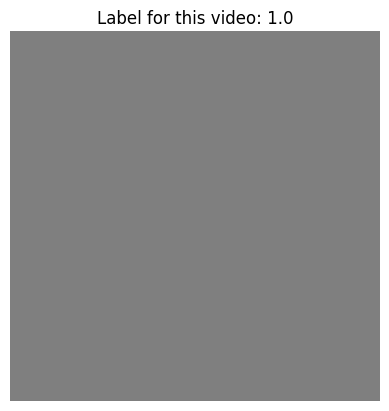

In [7]:
import matplotlib.pyplot as plt
from src.generator import VideoGenerator

# 1. Initialize the new generator
debug_gen = VideoGenerator(
    csv_path="/content/drive/MyDrive/VisionGuard/metadata.csv",
    batch_size=8,
    seq_len=16,
    shuffle=True # This is the magic fix
)

# 2. Pull the very first batch
X, y = debug_gen[0]

# 3. Print the results
print("--- 🛠️ Generator Sanity Check 🛠️ ---")
print(f"Batch Shape: {X.shape}") # Should be (8, 16, 224, 224, 3)
print(f"Labels in this batch: {y}") 
print(f"Pixel Range: Min={X.min():.2f}, Max={X.max():.2f}") # Should be approx -1.0 to 1.0

# 4. Check for class diversity
unique_classes = len(set(y))
if unique_classes > 1:
    print("✅ SUCCESS: Batch contains both Violence and Non-Violence. Shuffling is working!")
else:
    print("⚠️ WARNING: Only one class found in this batch. If this happens twice, shuffling failed.")

# 5. Visualize the first frame of the first video in the batch
plt.imshow((X[0][0] + 1) / 2) # Rescale from [-1,1] to [0,1] for display
plt.title(f"Label for this video: {y[0]}")
plt.axis('off')
plt.show()

In [ ]:
from tensorflow.keras.callbacks import CSVLogger, ModelCheckpoint
import os

# 1. Define where to save your results on Drive
checkpoint_path = "/content/drive/MyDrive/VisionGuard/visionguard_best_model.keras"
log_path = "/content/drive/MyDrive/VisionGuard/training_log.csv"

# 2. Add 'Callbacks' (Safety features)
# CSVLogger: Saves accuracy/loss to a CSV file so you have a backup
# ModelCheckpoint: Saves the 'Best' version of your AI if it improves
callbacks = [
    CSVLogger(log_path, append=False),
    ModelCheckpoint(checkpoint_path, save_best_only=True, monitor='accuracy')
]

print("--- 🚀 Starting Academic Training 🚀 ---")
print("Note: This will take 15-30 minutes on a T4 GPU.")

# 3. THE ACTUAL TRAINING
# This creates the 'history' variable once it hits 100%
history = model.fit(
    train_generator,
    epochs=20,
    callbacks=callbacks,
    verbose=1
)

# 4. Final Save
model.save("/content/drive/MyDrive/VisionGuard/visionguard_final_model.keras")
print("\n✅ Training Complete!")
print(f"Model saved to: {checkpoint_path}")
print(f"Logs saved to: {log_path}")

NameError: name 'history' is not defined

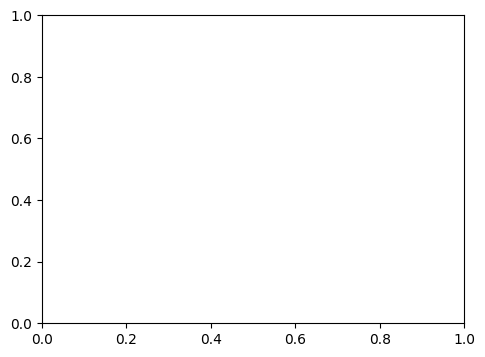

In [13]:
import matplotlib.pyplot as plt

# 1. Plot Training Accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue', linewidth=2)
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
# Access the specific metric name used in Cell 3
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# 2. Plot Training Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='red', linewidth=2)
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (Binary Crossentropy)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('training_performance.png') # Saves the graph to your Drive
plt.show()

print("--- Evaluation Metrics ---")
final_acc = history.history['accuracy'][-1]
print(f"Final Training Accuracy: {final_acc*100:.2f}%")